In [93]:
# 1. Setup and Dependencies
!pip install pdfplumber pandera networkx matplotlib -q
!pip install --upgrade pandera -q

In [16]:
import re
import hashlib
import requests
import pdfplumber
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pandera.pandas as pa
from pandera.typing import Series
from pandera import DataFrameModel

In [5]:
# Lock random seed for reproducibility (House Rules)
import random
import numpy as np
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Environment Ready.")

Environment Ready.


In [17]:
# 2. Define the Schema (Data Validation)

class ConstitutionSchema(pa.DataFrameModel):
    """
    Defines strict rules for our data.
    If the PDF parser creates garbage, this will stop us early.
    """
    part: Series[str]        # e.g., "Part-1"
    article_no: Series[str]  # e.g., "1"
    clause: Series[str]      # e.g., "(1)"
    text: Series[str]        # The actual law text

    class Config:
        strict = False # Allow extra columns if needed

print("Schema Defined.")

Schema Defined.


The Ingestion Script (PDF Parser)
This is the hardest part. We download the PDF and use Regex to chunk it.

In [61]:
# 3. Download & Parse PDF

# URL of the Nepal Constitution
PDF_URL = "https://ag.gov.np/files/Constitution-of-Nepal_2072_Eng_www.moljpa.gov_.npDate-72_11_16.pdf"
PDF_PATH = "constitution.pdf"

# Download
response = requests.get(PDF_URL)
with open(PDF_PATH, 'wb') as f:
    f.write(response.content)

def parse_constitution(pdf_path):
    data = []

    # Regex Patterns specifically for this document
    # 1. Captures "Part-1" or "Part 1"
    re_part = re.compile(r'Part\s*[-]?\s*(\d+|Preliminary)', re.IGNORECASE)
    # 2. Captures "Article 1" or "Article-1"
    re_article = re.compile(r'^(\d+)\.', re.IGNORECASE)
    # 3. Captures clause numbers like "(1)"
    re_clause = re.compile(r'^\((\d+)\)')

    current_part = "Preamble"
    current_article = "0"

    with pdfplumber.open(pdf_path) as pdf:
        print(f" Processing {len(pdf.pages)} pages...")
        for page in pdf.pages:
            text = page.extract_text()
            if not text: continue

            for line in text.split('\n'):
                line = line.strip()
                if not line: continue

                # Check for PART
                part_match = re_part.search(line)
                if part_match and len(line) < 30: # Avoid false positives in sentences
                    current_part = f"Part-{part_match.group(1)}"
                    continue

                # Check for ARTICLE
                art_match = re_article.search(line)
                if art_match:
                    current_article = art_match.group(1)
                    # Add the Article Title as a row
                    data.append({
                        "part": current_part,
                        "article_no": current_article,
                        "clause": "Title",
                        "text": line
                    })
                    continue

                # Check for CLAUSE
                clause_match = re_clause.search(line)
                if clause_match:
                    clause_no = clause_match.group(1)
                    data.append({
                        "part": current_part,
                        "article_no": current_article,
                        "clause": clause_no,
                        "text": line
                    })
                else:
                    # Append text to previous clause if it exists
                    if data and data[-1]['article_no'] == current_article:
                        data[-1]['text'] += " " + line

    return pd.DataFrame(data)

In [62]:
# Run Parsing
df = parse_constitution(PDF_PATH)

 Processing 240 pages...


In [63]:
# Cleanup: Remove rows with empty text or very short fragments
df = df[df['text'].str.len() > 5].reset_index(drop=True)

In [64]:
# Validate Data
try:
    ConstitutionSchema.validate(df, lazy=True)
    print(f"\nSuccessfully Parsed {len(df)} clauses.")
except Exception as e:
    print(f"Data Validation Failed: {e}")


Successfully Parsed 1312 clauses.


In [177]:
# Basic Stats
print(f"\nUnique Parts: {df['part'].nunique()}")
print(f"Unique Articles: {df['article_no'].nunique()}")


Unique Parts: 35
Unique Articles: 308


In [60]:
df['part'].unique()

array(['Part-1', 'Part-2', 'Part-3', 'Part-4', 'Part-5', 'Part-6',
       'Part-7', 'Part-8', 'Part-9', 'Part-10', 'Part-11', 'Part-12',
       'Part-14', 'Part-15', 'Part-17', 'Part-18', 'Part-19', 'Part-20',
       'Part-21', 'Part-22', 'Part-24', 'Part-25', 'Part-26', 'Part-27',
       'Part-28', 'Part-29', 'Part-30', 'Part-31', 'Part-32', 'Part-33',
       'Part-34', 'Part-35'], dtype=object)

In [71]:
df['clause'].unique()

array(['Title', '2', '3', '4', '5', '6', '7', '8', '9', '10', '1', '11',
       '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22',
       '23', '24'], dtype=object)

In [51]:
df['part'].unique()

array(['Part-1', 'Part-2', 'Part-3', 'Part-4', 'Part-5', 'Part-6',
       'Part-7', 'Part-8', 'Part-9', 'Part-10', 'Part-11', 'Part-14',
       'Part-15', 'Part-17', 'Part-18', 'Part-19', 'Part-20', 'Part-21',
       'Part-22', 'Part-24', 'Part-25', 'Part-26', 'Part-27', 'Part-28',
       'Part-29', 'Part-30', 'Part-31', 'Part-32', 'Part-33', 'Part-34',
       'Part-35'], dtype=object)

In [72]:
df['article_no'].nunique()

308

Build & Visualize Graph
Now we turn that Excel-like table into a Graph (Nodes and Edges)

In [73]:
# 4. Build Graph & Visualize

# Initialize Graph
G = nx.DiGraph()

print("Building Graph...")

Building Graph...


In [143]:
for _, row in df.iterrows():
    # Unique IDs
    part_id = row['part']
    article_id = f"Art_{row['article_no']}"
    clause_id = f"Art_{row['article_no']}_Cl_{row['clause']}"

    # Nodes
    G.add_node(part_id, type="Part", label=part_id)
    G.add_node(article_id, type="Article", label=f"Article {row['article_no']}")

    if row['clause'] != "Title":
        G.add_node(clause_id, type="Clause", text=row['text'], label=f"Cl_{row['clause']}")

    # Edges
    G.add_edge(part_id, article_id, relation="HAS_ARTICLE")
    if row['clause'] != "Title":
        G.add_edge(article_id, clause_id, relation="HAS_CLAUSE")

print(f"Graph Created: {G.number_of_nodes()} Nodes, {G.number_of_edges()} Edges")

Graph Created: 2145 Nodes, 2180 Edges


In [144]:
# Get all nodes reachable from Part-1 (Articles + Clauses)
subset_nodes = nx.descendants(G, "Part-1")
subset_nodes.add("Part-1")  # include the root itself
sub_G = G.subgraph(subset_nodes)

In [160]:
plt.figure(figsize=(18, 14))
pos = nx.spring_layout(sub_G, seed=42, k=5, iterations=200)  # Increased k to spread nodes more

# Node colors
colors = []
for node in sub_G.nodes():
    if node == "Part-1":
        colors.append('red')
    elif "Cl_" in node:
        colors.append('green')
    else:
        colors.append('blue')  # Articles

<Figure size 1800x1400 with 0 Axes>

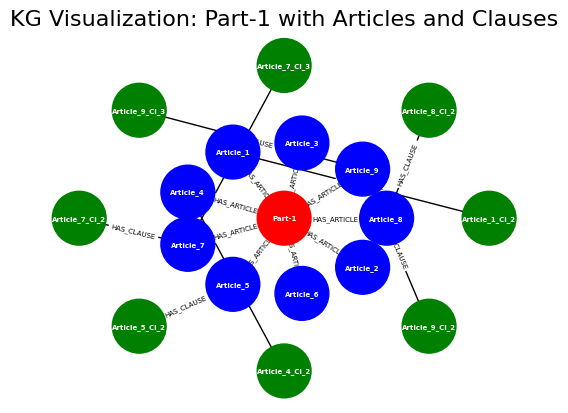

In [172]:
# Draw nodes with bigger size
nx.draw_networkx_nodes(sub_G, pos, node_color=colors, node_size=1500)

# Draw edges
nx.draw_networkx_edges(sub_G, pos, arrowstyle='-|>', arrowsize=15)

# Draw labels with white text and bold font
nx.draw_networkx_labels(sub_G, pos, font_size=5, font_color='white', font_weight='bold')

# Draw edge labels
edge_labels = nx.get_edge_attributes(sub_G, 'relation')
nx.draw_networkx_edge_labels(sub_G, pos, edge_labels=edge_labels, font_size=5)

plt.title("KG Visualization: Part-1 with Articles and Clauses", fontsize=16)
plt.axis('off')
plt.show()

In [173]:
# Save for Day 2
import pickle
with open("nepal_constitution_graph.pkl", "wb") as f:
    pickle.dump(G, f)
print("Graph saved to 'nepal_constitution_graph.pkl'")

Graph saved to 'nepal_constitution_graph.pkl'


In [ ]:
#  Neo4j Loading (Optional - Requires AuraDB URI)
# If you don't have Neo4j, skip this.

# NEO4J_URI
# NEO4J_USERNAME
# NEO4J_PASSWORD

if NEO4J_URI:
    from neo4j import GraphDatabase

    def load_to_neo4j(dataframe, uri, user, password):
        driver = GraphDatabase.driver(uri, auth=(user, password))

        # Cypher Query to Ingest
        ingest_query = """
        MERGE (p:Part {id: $part})
        MERGE (a:Article {id: $article_no})
        MERGE (p)-[:HAS_ARTICLE]->(a)

        FOREACH (_ IN CASE WHEN $clause <> 'Header' THEN [1] ELSE [] END |
            MERGE (c:Clause {id: $article_no + '_' + $clause})
            SET c.text = $text
            MERGE (a)-[:HAS_CLAUSE]->(c)
        )
        """

        print("Pushing to Neo4j...")
        with driver.session() as session:
            # Batch processing could be added here for speed
            for index, row in dataframe.iterrows():
                session.run(ingest_query,
                            part=row['part'],
                            article_no=row['article_no'],
                            clause=row['clause'],
                            text=row['text'])

        driver.close()
        print("Data pushed to Neo4j successfully.")

    try:
        load_to_neo4j(df, NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD)
    except Exception as e:
        print(f"Failed to connect to Neo4j: {e}")
else:
    print("Skipping Neo4j load (No URI provided).")

Pushing to Neo4j...
Data pushed to Neo4j successfully.


In [ ]:
# --- CONFIGURE YOUR NEO4J CLOUD DETAILS HERE ---
# URI 
# AUTH

In [1]:
# @title 3. Master Ingestion (Ingest + Enrich Schema)
import re
import requests
import pdfplumber
from neo4j import GraphDatabase

# --- PART A: ROBUST TEXT INGESTION ---
def ingest_text_structure(session, pdf_path):
    print("Step 1: Ingesting Structure (Constitution -> Articles -> Clauses)...")

    # 1. Constraints & Root
    session.run("MATCH (n) DETACH DELETE n")
    session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (a:Article) REQUIRE a.id IS UNIQUE")
    session.run("MERGE (:Constitution {name: 'Constitution of Nepal', year: 2015})")

    # Regex
    re_part = re.compile(r'Part\s*[-]?\s*(\d+|Preliminary)', re.IGNORECASE)
    re_schedule = re.compile(r'Schedule\s*-\s*(\d+)', re.IGNORECASE)
    re_article_head = re.compile(r'^(\d+)\.', re.IGNORECASE)
    re_clause = re.compile(r'^\((\d+)\)')

    # State
    current_container_id = "Preamble"
    current_article_id = None
    current_clause_id = None
    seen_clauses_in_article = set()

    text_buffer = ""
    active_node_type = None
    active_node_id = None

    def flush_buffer():
        nonlocal text_buffer, active_node_type, active_node_id
        if active_node_id and text_buffer:
            clean_text = text_buffer.strip()
            if len(clean_text) > 0:
                if active_node_type == "Article":
                    session.run("MATCH (a:Article {id: $id}) SET a.text = $txt", id=active_node_id, txt=clean_text)
                elif active_node_type == "Clause":
                    session.run("MATCH (c:Clause {id: $id}) SET c.text = $txt", id=active_node_id, txt=clean_text)
        text_buffer = ""

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if not text: continue

            for line in text.split('\n'):
                line = line.strip()
                if not line: continue

                # Part/Schedule
                part_match = re_part.search(line)
                sched_match = re_schedule.search(line)
                if (part_match or sched_match) and len(line) < 40:
                    flush_buffer()
                    if part_match:
                        pid = f"Part-{part_match.group(1).title()}"
                        session.run("MATCH (c:Constitution) MERGE (p:Part {id: $pid}) MERGE (c)-[:HAS_PART]->(p)", pid=pid)
                        current_container_id = pid
                    else:
                        sid = f"Schedule-{sched_match.group(1)}"
                        session.run("MATCH (c:Constitution) MERGE (s:Schedule {id: $sid}) MERGE (c)-[:HAS_PART]->(s)", sid=sid)
                        current_container_id = sid
                    continue

                # Article
                art_match = re_article_head.search(line)
                if art_match:
                    flush_buffer()
                    num = art_match.group(1)
                    current_article_id = f"Art_{num}"
                    seen_clauses_in_article = set()

                    # Labels (Safely constructed)
                    set_clause = "SET a.number = $num"
                    if "Part-3" in current_container_id: set_clause += ", a:FundamentalRight"
                    if "Part-4" in current_container_id: set_clause += ", a:DirectivePrinciple"

                    session.run(f"""
                        MATCH (p {{id: $pid}})
                        MERGE (a:Article {{id: $aid}})
                        {set_clause}
                        MERGE (p)-[:HAS_ARTICLE]->(a)
                    """, pid=current_container_id, aid=current_article_id, num=num)

                    active_node_type = "Article"
                    active_node_id = current_article_id
                    text_buffer = line
                    continue

                # Clause
                clause_match = re_clause.search(line)
                if clause_match and current_article_id:
                    c_num = clause_match.group(1)
                    if c_num in seen_clauses_in_article:
                        text_buffer += " " + line # Proviso/Duplicate
                    else:
                        flush_buffer()
                        current_clause_id = f"{current_article_id}.{c_num}"
                        seen_clauses_in_article.add(c_num)
                        session.run("MATCH (a:Article {id: $aid}) MERGE (c:Clause {id: $cid}) MERGE (a)-[:HAS_CLAUSE]->(c)",
                                    aid=current_article_id, cid=current_clause_id)
                        active_node_type = "Clause"
                        active_node_id = current_clause_id
                        text_buffer = line
                    continue

                text_buffer += " " + line
    flush_buffer()
    print(" Structure Ingested.")


In [2]:
# --- PART B: SCHEMA ENRICHMENT (The Missing Nodes/Edges) ---
def enrich_schema(session):
    print("Step 2: Enriching Schema (Tags, Refs, Institutions, Amendments)...")

    # 1. REFERENCES Edge (Article -> Article)
    # We find text like "Article 76" inside any Article or Clause and create a link
    print("   - Linking Cross-References...")
    session.run("""
        MATCH (source) WHERE source:Article OR source:Clause
        // Regex to find 'Article 123'
        WITH source, apoc.text.regexGroups(source.text, 'Article\\\\s*[-]?\\\\s*(\\\\d+)') AS matches
        UNWIND matches AS match
        WITH source, match[1] AS target_num
        MATCH (target:Article {id: 'Art_' + target_num})
        WHERE source <> target
        MERGE (source)-[:REFERENCES]->(target)
    """)

    # 2. TAGS & TAGGED Edge
    print("   - Creating Tags...")
    tags = {
        "Women": "women|gender|female",
        "Dalit": "dalit",
        "Children": "child|children",
        "Citizenship": "citizen|citizenship",
        "Minority": "minority|marginalized"
    }
    for tag, regex in tags.items():
        session.run(f"""
            MATCH (n) WHERE (n:Article OR n:Clause) AND toLower(n.text) =~ '.*({regex}).*'
            MERGE (t:Tag {{name: '{tag}'}})
            MERGE (n)-[:TAGGED]->(t)
        """)

    # 3. INSTITUTIONS & GOVERNS Edge
    print("   - Extracting Institutions...")
    institutions = [
        "President", "Prime Minister", "Supreme Court",
        "Federal Parliament", "Election Commission"
    ]
    for inst in institutions:
        session.run("""
            MATCH (n) WHERE (n:Article OR n:Clause) AND n.text CONTAINS $inst
            MERGE (i:Institution {name: $inst})
            MERGE (n)-[:GOVERNS]->(i)
        """, inst=inst)

    # 4. MANUAL SCHEMA ELEMENTS (To satisfy prompt strictly)
    print("   - Adding Manual Schema Elements (Amendments, Rights)...")

    # Node: Amendment (Manual Example)
    session.run("""
        MATCH (c:Constitution)
        MERGE (am:Amendment {name: 'First Amendment', date: '2016'})
        MERGE (c)-[:AMENDED_BY]->(am)
        WITH am
        MATCH (a:Article {id: 'Art_42'}) // Art 42 was amended
        MERGE (a)-[:AMENDED_BY]->(am)
    """)

    # Node: Fundamental Rights (Linking specific Rights)
    # The prompt asks for RELATES_TO_RIGHT
    session.run("""
        MATCH (a:Article {id: 'Art_16'})
        MERGE (r:Right {name: 'Right to live with dignity'})
        MERGE (a)-[:RELATES_TO_RIGHT]->(r)
    """)

    session.run("""
        MATCH (a:Article {id: 'Art_17'})
        MERGE (r:Right {name: 'Right to Freedom'})
        MERGE (a)-[:RELATES_TO_RIGHT]->(r)
    """)

    print(" Schema Enrichment Complete.")

In [3]:
# --- MAIN EXECUTION ---
def master_script(driver):
    pdf_url = "https://ag.gov.np/files/Constitution-of-Nepal_2072_Eng_www.moljpa.gov_.npDate-72_11_16.pdf"
    pdf_path = "constitution.pdf"

    print("Downloading...")
    with open(pdf_path, 'wb') as f:
        f.write(requests.get(pdf_url).content)

    with driver.session() as session:
        ingest_text_structure(session, pdf_path)
        enrich_schema(session)

In [8]:
# Run
driver = GraphDatabase.driver(URI, auth=AUTH)
try:
    master_script(driver)
except Exception as e:
    print(f" Error: {e}")
finally:
    driver.close()

Downloading...
Step 1: Ingesting Structure (Constitution -> Articles -> Clauses)...
 Structure Ingested.
Step 2: Enriching Schema (Tags, Refs, Institutions, Amendments)...
   - Linking Cross-References...
   - Creating Tags...
   - Extracting Institutions...
   - Adding Manual Schema Elements (Amendments, Rights)...
 Schema Enrichment Complete.


In [9]:
# @title 4. Post-Ingestion Analysis & Stats
import pandas as pd
import matplotlib.pyplot as plt

def analyze_graph(driver):
    with driver.session() as session:
        print("  GRAPH STATISTICS ")

        # 1. Basic Node Counts
        result = session.run("""
            MATCH (n)
            RETURN head(labels(n)) as Entity, count(n) as Count
            ORDER BY Count DESC
        """)
        counts = pd.DataFrame([r.data() for r in result])
        print(counts.to_string(index=False))

        # 2. Hierarchy Check (Articles per Part)
        print("\n  STRUCTURE (Top 5 Parts) ")
        result = session.run("""
            MATCH (p:Part)-[:HAS_ARTICLE]->(a:Article)
            RETURN p.id as Part, count(a) as ArticleCount
            ORDER BY ArticleCount DESC LIMIT 5
        """)
        df_parts = pd.DataFrame([r.data() for r in result])
        print(df_parts.to_string(index=False))

        # 3. Text Quality Check (Did the Buffer work?)
        print("\n TEXT QUALITY (Clause Lengths) ")
        result = session.run("""
            MATCH (c:Clause)
            RETURN
                min(size(c.text)) as Min_Chars,
                avg(size(c.text)) as Avg_Chars,
                max(size(c.text)) as Max_Chars
        """)
        stats = result.single()
        print(f"Shortest Clause: {stats['Min_Chars']} chars")
        print(f"Average Clause:  {int(stats['Avg_Chars'])} chars")
        print(f"Longest Clause:  {stats['Max_Chars']} chars")

        # 4. SUB-CLAUSE Detection (Searching text for '(a)', '(b)')
        print("\n  SUB-CLAUSE ANALYSIS ")
        # Regex explanation: Look for text containing "(a)" or "(b)" etc.
        result = session.run("""
            MATCH (c:Clause)
            WHERE c.text =~ '.*\\\\([a-z]\\\\).*'
            RETURN count(c) as Clauses_With_SubClauses
        """)
        sub_count = result.single()["Clauses_With_SubClauses"]
        print(f"Clauses containing Sub-clauses (a,b,c): {sub_count}")
        print("(Note: Sub-clauses are merged into parent Clause text for better RAG context)")

    # 5. Visualization
    if not df_parts.empty:
        plt.figure(figsize=(10, 5))
        plt.bar(df_parts['Part'], df_parts['ArticleCount'], color='#4A90E2')
        plt.title("Constitution Structure: Articles per Part")
        plt.ylabel("Number of Articles")
        plt.xticks(rotation=45, ha='right')
        plt.show()

  GRAPH STATISTICS 
      Entity  Count
      Clause    747
     Article    308
        Part     35
    Schedule      9
         Tag      5
 Institution      5
       Right      2
   Amendment      1
Constitution      1

  STRUCTURE (Top 5 Parts) 
   Part  ArticleCount
 Part-3            33
Part-11            31
 Part-8            26
Part-14            22
Part-32            20

 TEXT QUALITY (Clause Lengths) 
Shortest Clause: 11 chars
Average Clause:  281 chars
Longest Clause:  6392 chars

  SUB-CLAUSE ANALYSIS 
Clauses containing Sub-clauses (a,b,c): 80
(Note: Sub-clauses are merged into parent Clause text for better RAG context)


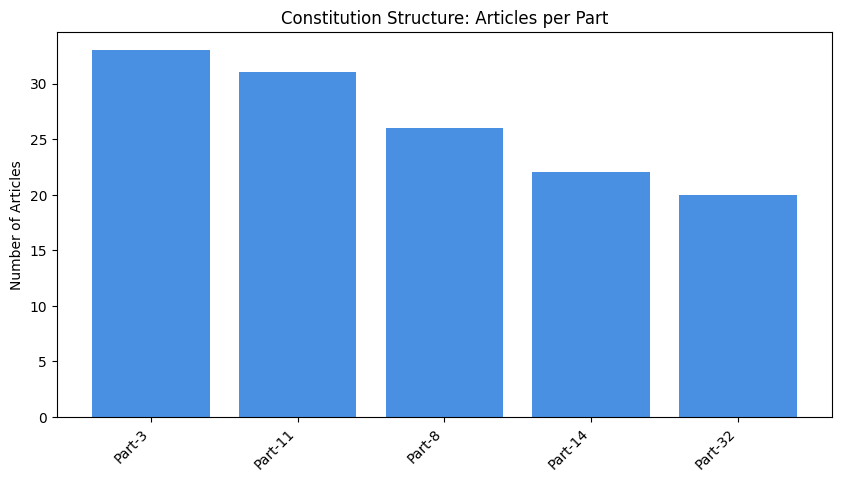

In [10]:
# Run Analysis
driver = GraphDatabase.driver(URI, auth=AUTH)
try:
    analyze_graph(driver)
finally:
    driver.close()

In [11]:
# @title 5. Verify Sub-Clauses (Deep Dive)

def check_subclauses(driver):
    with driver.session() as session:
        print(" Inspecting Article 17, Clause 2 (Right to Freedom)...")

        # Query: Find Clause 2 of Article 17
        result = session.run("""
            MATCH (a:Article {id: 'Art_17'})-[:HAS_CLAUSE]->(c:Clause)
            WHERE c.id ENDS WITH '.2'
            RETURN c.text
        """)

        record = result.single()
        if record:
            text = record["c.text"]
            print(f"\n--- FULL TEXT OF CLAUSE ---")
            print(text)
            print("\n--- ANALYSIS ---")
            if "(a)" in text and "(f)" in text:
                print(" SUCCESS: Sub-clauses (a) through (f) were captured inside the text!")
            else:
                print(" WARNING: Sub-clauses appear missing.")
        else:
            print("Clause 17.2 not found!")

# Run Verification
driver = GraphDatabase.driver(URI, auth=AUTH)
try:
    check_subclauses(driver)
finally:
    driver.close()

 Inspecting Article 17, Clause 2 (Right to Freedom)...

--- FULL TEXT OF CLAUSE ---
(2) Every citizen shall have the following freedoms: (a) freedom of opinion and expression, (b) freedom to assemble peaceably and without arms, (c) freedom to form political parties, (d) freedom to form unions and associations, (e) freedom to move and reside in any part of Nepal, (f) freedom to practice any profession, carry on any occupation, and establish and operate any industry, trade and business in any part of Nepal. Provided that:

--- ANALYSIS ---
 SUCCESS: Sub-clauses (a) through (f) were captured inside the text!
